In [1]:
!pip install transformers datasets arabert sentencepiece tensorflow torch scikit-learn matplotlib seaborn --quiet 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf 24.8.0 requires numpy<2.0a0,>=1.23, but you have numpy 2.2.6 which is incompatible.
cudf 24.8.0 requires pyarrow<16.2.0a0,>=16.1.0, but you have pyarrow 22.0.0 which is incompatible.
cugraph 24.8.0 requires numpy<2.0a0,>=1.23, but you have numpy 2.2.6 which is incompatible.
cugraph-dgl 24.8.0 requires numpy<2.0a0,>=1.23, but you have numpy 2.2.6 which is incompatible.
cugraph-pyg 24.8.0 requires numpy<2.0a0,>=1.23, but you have numpy 2.2.6 which is incompatible.
cugraph-service-server 24.8.0 requires numpy<2.0a0,>=1.23, but you have numpy 2.2.6 which is incompatible.
dask-cuda 24.8.0 requires numpy<2.0a0,>=1.23, but you have numpy 2.2.6 which is incompatible.
dask-cudf 24.8.0 requires numpy<2.0a0,>=1.23, but you have numpy 2.2.6 which is incompatible.
kvikio 24.8.0 requires numpy<2.0a0,>=1.23, but you have nu

In [2]:
!pip install tf-keras

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 13.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

print("TensorFlow GPU:", tf.config.list_physical_devices('GPU'))
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print("GPU in use:", device)
print("PyTorch GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2025-11-09 08:57:58.680252: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.p

TensorFlow GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:4', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:5', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:6', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:7', device_type='GPU')]
GPU in use: cuda:2
PyTorch GPU: NVIDIA A100-SXM4-40GB


In [4]:
df = pd.read_csv("arabic_dataset_classifiction.csv")

# Fix mislabeled column
df = df.rename(columns={"targe": "target"})

# Drop empty texts
df = df.dropna(subset=["text"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (108789, 2)


,text,target
0,بين أستوديوهات ورزازات وصحراء مرزوكة وآثار ولي...,0
1,قررت النجمة الأمريكية أوبرا وينفري ألا يقتصر ع...,0
2,أخبارنا المغربية الوزاني تصوير الشملالي ألهب ا...,0
3,اخبارنا المغربية قال ابراهيم الراشدي محامي سعد...,0
4,تزال صناعة الجلود في المغرب تتبع الطريقة التقل...,0


In [5]:
print(df["target"].value_counts())

df["text_length"] = df["text"].str.len()
print(df["text_length"].describe())

# Clean text slightly
def clean_text(x):
    if not isinstance(x, str):
        return ""
    x = x.strip()
    return x

df["text"] = df["text"].apply(clean_text)

# Final clean dataset
df = df[df["text"] != ""]
print("Cleaned:", df.shape)

target
4    43675
3    20485
1    16728
2    14165
0    13736
Name: count, dtype: int64
count    108789.000000
mean       1553.717343
std        1226.763083
min           2.000000
25%         752.000000
50%        1251.000000
75%        1970.000000
max       28083.000000
Name: text_length, dtype: float64
Cleaned: (108789, 3)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["target"],
    test_size=0.2,
    random_state=42,
    stratify=df["target"]
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 87031
Test size: 21758


SVM Accuracy: 0.9607960290467874
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2747
           1       0.96      0.98      0.97      3346
           2       0.91      0.90      0.91      2833
           3       0.92      0.93      0.92      4097
           4       0.99      0.99      0.99      8735

    accuracy                           0.96     21758
   macro avg       0.95      0.95      0.95     21758
weighted avg       0.96      0.96      0.96     21758



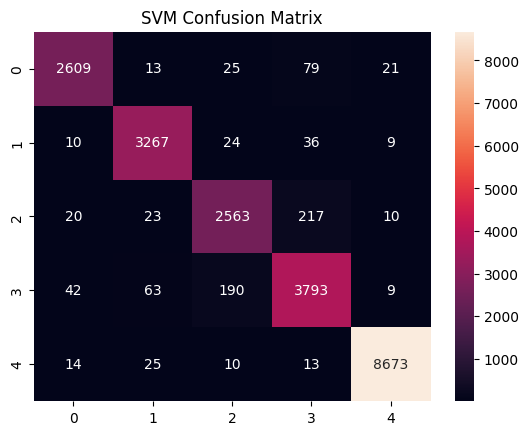

In [7]:
vectorizer = TfidfVectorizer(max_features=50000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

svm = LinearSVC()
svm.fit(X_train_vec, y_train)

pred_svm = svm.predict(X_test_vec)
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

print(classification_report(y_test, pred_svm))

cm = confusion_matrix(y_test, pred_svm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.show()

Naive Bayes Accuracy: 0.9425958268223182
              precision    recall  f1-score   support

           0       0.96      0.91      0.93      2747
           1       0.93      0.96      0.94      3346
           2       0.91      0.88      0.89      2833
           3       0.87      0.92      0.89      4097
           4       0.99      0.98      0.99      8735

    accuracy                           0.94     21758
   macro avg       0.93      0.93      0.93     21758
weighted avg       0.94      0.94      0.94     21758



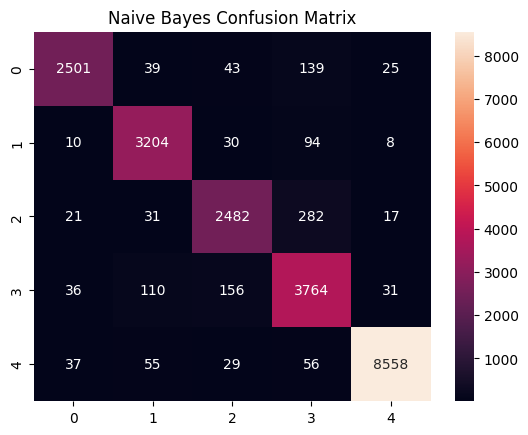

In [8]:
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

pred_nb = nb.predict(X_test_vec)
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))

print(classification_report(y_test, pred_nb))

cm = confusion_matrix(y_test, pred_nb)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1762678784.013391     240 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 28044 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:07:00.0, compute capability: 8.0


Epoch 1/5


I0000 00:00:1762678784.015745     240 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38380 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:0f:00.0, compute capability: 8.0
I0000 00:00:1762678784.017792     240 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 34422 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:47:00.0, compute capability: 8.0
I0000 00:00:1762678784.022794     240 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38380 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:4e:00.0, compute capability: 8.0
I0000 00:00:1762678784.024821     240 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:4 with 1129 MB memory:  -> device: 4, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:87:00.0, compute capability: 8.0
I0000 00:00:1762678784.027678     240 gpu_device.cc:2020] Created

1224/1224 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.8496 - loss: 0.4297 - val_accuracy: 0.9321 - val_loss: 0.2450
Epoch 2/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 49s 40ms/step - accuracy: 0.9353 - loss: 0.2156 - val_accuracy: 0.9413 - val_loss: 0.2015
Epoch 3/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.9625 - loss: 0.1310 - val_accuracy: 0.9306 - val_loss: 0.2467
Epoch 4/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.9789 - loss: 0.0756 - val_accuracy: 0.9350 - val_loss: 0.2434
Epoch 5/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.9843 - loss: 0.0541 - val_accuracy: 0.9374 - val_loss: 0.2794
680/680 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9357 - loss: 0.2745
LSTM Accuracy: 0.9357017874717712
680/680 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step


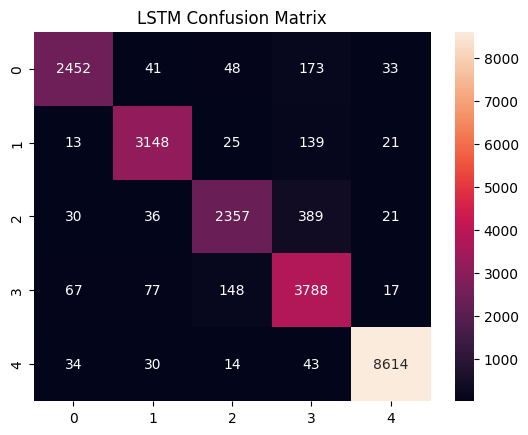

In [9]:
MAX_WORDS = 50000
MAX_LEN = 200

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>")
tokenizer_lstm.fit_on_texts(X_train)

train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train), maxlen=MAX_LEN)
test_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test), maxlen=MAX_LEN)

model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(train_seq, y_train, validation_split=0.1, epochs=5, batch_size=64)

loss, acc = model.evaluate(test_seq, y_test)
print("LSTM Accuracy:", acc)

pred_lstm = np.argmax(model.predict(test_seq), axis=1)

cm = confusion_matrix(y_test, pred_lstm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.show()

In [10]:
import numpy as np
print("NumPy version:", np.__version__)
print("NumPy path:", np.__path__)


NumPy version: 2.2.6
NumPy path: ['/usr/local/lib/python3.10/dist-packages/numpy']


In [14]:
import torch, transformers, accelerate
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Torch:", torch.__version__)

from transformers import Trainer, TrainingArguments
print("Trainer loaded successfully!")

Transformers: 4.57.1
Accelerate: 1.11.0
Torch: 2.5.0a0+e000cf0ad9.nv24.10
Trainer loaded successfully!
